
СОЗДАЕМ ЭМБЕДИНГИ
---



In [6]:
import requests
import numpy as np
from scipy.spatial.distance import cdist

FOLDER_ID = "Ваш FOLDER_ID"  # Ваш folder_id (посмотрите в адресной строке)
API_KEY = "Ваш API_KEY"       # Который получите после нажатия кнопки

# URI моделей
doc_uri = f"emb://{FOLDER_ID}/text-search-doc/latest"
query_uri = f"emb://{FOLDER_ID}/text-search-query/latest"
embed_url = "https://ai.api.cloud.yandex.net:443/foundationModels/v1/textEmbedding"

# Для API-ключа используем Authorization: Api-Key
headers = {
    "Content-Type": "application/json",
    "Authorization": f"Api-Key {API_KEY}",  # ВАЖНО: именно Api-Key, а не Bearer
    "x-folder-id": FOLDER_ID
}

def get_embedding(text: str, text_type: str = "doc") -> np.array:
    query_data = {
        "modelUri": doc_uri if text_type == "doc" else query_uri,
        "text": text,
    }

    response = requests.post(embed_url, json=query_data, headers=headers)

    if response.status_code != 200:
        print(f"Ошибка {response.status_code}: {response.text}")
        return None

    return np.array(response.json()["embedding"])


In [10]:
doc_texts = [
    """Электрическая зубная щетка Oral-B Vitality Starter Pack D100.423.1
Oral-B Vitality — самая доступная электрическая щетка, работающая от аккумулятора! Клинически доказано, что электрическая зубная щетка Oral-B Vitality чистит зубы значительно эффективнее мануальной зубной щетки. Технология 2D Cleaning Action с возвратно-вращательными движениями удаляет налет лучше, чем обычная зубная щетка, а закругленные кончики щетинок обеспечивают безопасность применения. Щетка работает с одним режимом работы и с встроенным таймером. В комлект входит зарядное устройство и две сменные насадки.""",
    """Электрическая зубная щетка Soocas X3U PRO (черная)
Электрическая зубная щетка Soocas X3u Pro - это современное и эффективное устройство для ухода за полостью рта. Она оснащена звуковым двигателем с магнитной левитацией, который обеспечивает глубокую очистку и бережное отбеливание зубов. Особенностью щетки является функция стерилизации. Всего за 5 минут она уничтожает 99,99% бактерий, оседающих на корпусе. Это обеспечивает безопасное использование щетки и предотвращает неприятные запахи изо рта. Щетка оснащена 4 комбинированными режимами работы, включая ежедневный режим, режим отбеливания, щадящий режим для новичков и людей с чувствительными зубами, а также режим полировки.""",
    """лектрическая зубная щетка Philips Sonicare HX3651/12 2100 Series
Philips Sonicare 2100 Series HX3651/12 — простая в использовании электрическая звуковая зубная щетка с технологией Sonicare с одним режимом чистки и насадкой для удаления налета в комплекте. Можно использовать в возрасте от 12 лет. В щетку встроен таймер, функция Easy-start для комфортного привыкания к использованию электрической щетки. Запатентованная звуковая технология чистки SoniCare обеспечивает эффективную и абсолютно безопасную чистку даже при наличии каких-либо видов ортодонтических конструкций.

ВАЖНО! Для использования с российским типом розеток может понадобится сетевой адаптер (для подключения устройств со штекером US/CN)""",
    """Пылесосы можно разделить на несколько групп по основному назначению:
Классические. Это мощные устройства, работающие от сети. Подходят для основательной и глубокой чистки ковров и мягкой мебели. Модели с мешками обеспечивают удобную утилизацию мусора, а с контейнером — экономят на расходниках.
Вертикальные. Лёгкие, компактные и манёвренные, созданы для быстрой повседневной уборки. Беспроводные модели дают полную свободу передвижения, позволяя убрать не только пол, но и пыль на полках или в салоне автомобиля.
Моющие. Это многофункциональные комбайны, которые могут выполнять сухую уборку, мыть гладкие полы, освежать ковры и собирать пролитые жидкости.""",
    """Электрическая зубная щётка — это щётка, щетинки которой вибрируют с помощью электрического моторчика. Как правило, моторчик встроен в корпус щётки и берёт питание от аккумулятора или батарейки. Щетинки вибрируют либо вверх-вниз, либо возвратно-вращательно.
Преимущества:
эффективность — щётки совершают от 20 000 до 60 000 колебаний в минуту, что позволяет быстро и качественно удалять налёт;
простота использования — не требуют сложной техники чистки, что особенно важно для людей с ограниченной подвижностью рук (детям, пожилым);
функциональность — многие электрические щётки оснащены различными режимами (для чувствительных зубов, брекетов и т. д.), таймерами, датчиками давления.
Недостатки:
стоимость — электрические щётки стоят дороже мануальных и требуют регулярной замены насадок;
зависимость от источника питания — нуждаются в регулярной зарядке, что может быть неудобно в поездках;
риск повреждения эмали и дёсен — при неправильном использовании или слишком сильном давлении есть вероятность травмирования тканей полости рта.
Виды
Некоторые виды электрических зубных щёток:
Ротационные — головка круглой формы, совершает возвратно-вращательные движения. Обрабатывают каждый зуб отдельно, проникая в межзубные промежутки и зубодесневые карманы.
Звуковые — электромагнит в устройстве раскачивает головку, создаёт звуковую волну, и колебания передаются по ворсинкам. Такие щётки скорее вибрируют, а не движутся, совершают от 30 000 до 62 000 колебаний в минуту.
Ультразвуковые — с помощью высокочастотных колебаний проникают в труднодоступные места, убирают налёт, даже твёрдые отложения, а также уничтожают бактерии. Ультразвуковые щётки имеют ограничения в использовании, поэтому перед их приобретением желательно проконсультироваться со стоматологом.
Критерии выбора
При выборе электрической зубной щётки стоит обратить внимание на следующие параметры:
Жёсткость щетины. Мягкая щетина рекомендована при чувствительных зубах или проблемах с дёснами, средняя жёсткость подходит для большинства людей. Жёсткие щетинки лучше использовать только по назначению врача, так как есть вероятность повреждения эмали или слизистой.
Режимы работы. Чем современнее и дороже модель, тем больше режимов — количество достигает 6–7. С помощью них можно регулировать интенсивность и количество оборотов движений щетинок в минуту.
Аккумулятор. Батарея должна хорошо держаться, чтобы не пришлось заряжать щётку слишком часто.
Тип движения. Бывают насадки с возвратно-вращательными движениями и пульсирующие. Первый вариант даёт более бережное очищение и подходит для людей с чувствительной эмалью, а также для детей и пожилых людей. Пульсирующие модели передают вибрацию в сочетании с круговыми движениями.
Наличие звукового сигнала и таймера. Помогает контролировать время чистки зубов и следить за тем, чтобы минуты были распределены равномерно между четырьмя зонами.
Правила использования
Некоторые рекомендации по использованию электрической зубной щётки:
Перед чисткой слегка намочить щетину щётки, нанести пасту — размером примерно с горошину (не больше, иначе будет много пены), убедиться, что щётка заряжена.
Включить щётку — лучше сделать это до того, как приложить её к зубам, чтобы избежать брызг.
Прижать головку щётки к зубам под углом 45° — так, чтобы щетина охватывала линию дёсен.
Перемещать щётку медленно — задерживаться на каждом зубе по 2–4 секунды.
Обрабатывать все поверхности: внешнюю (со стороны щёк), внутреннюю (со стороны языка) и жевательную.
На каждую из четырёх зон (верхняя внешняя, верхняя внутренняя, нижняя внешняя, нижняя внутренняя) уделить примерно 30 секунд — всего получится 2 минуты.
Если у щётки есть таймер, он подскажет, когда переходить к следующему участку или завершать чистку.
Важно: с электрощёткой не рекомендуется использовать отбеливающие зубные пасты — они обладают высокой абразивностью и могут нанести вред дёснам и эмали
"""

]
query_text = ["электрическая зубная щетка"]

In [11]:
# Получаем эмбеддинги
query_embedding = [get_embedding(query, text_type="query") for query in query_text]
docs_embedding = [get_embedding(doc_text) for doc_text in doc_texts]


In [12]:
print(len(query_embedding))
print(len(docs_embedding))

1
5


НАХОДИМ КОСИНУСНОЕ РАССТОЯНИЕ МЕЖДУ ЗАПРОСОМ И ДОКУМЕНТАМИ.

In [13]:
if query_embedding is not None and docs_embedding:
  for j, query in enumerate(query_embedding):
      print(f"Запрос №{j}")
      for i, doc_emb in enumerate(docs_embedding):
          # ИСПРАВЛЕНИЕ: делаем doc_emb двумерным, добавляя ось
          dist = cdist([query], [doc_emb], metric="cosine")
          sim = 1 - dist[0][0]

          print(f"\n{i+1}. Документ {i+1}")
          print(f"   Сходство: {sim:.4f}")
          print(f"   Текст: {doc_texts[i][:150]}...")

Запрос №0

1. Документ 1
   Сходство: 0.5001
   Текст: Электрическая зубная щетка Oral-B Vitality Starter Pack D100.423.1
Oral-B Vitality — самая доступная электрическая щетка, работающая от аккумулятора! ...

2. Документ 2
   Сходство: 0.4783
   Текст: Электрическая зубная щетка Soocas X3U PRO (черная)
Электрическая зубная щетка Soocas X3u Pro - это современное и эффективное устройство для ухода за п...

3. Документ 3
   Сходство: 0.5222
   Текст: лектрическая зубная щетка Philips Sonicare HX3651/12 2100 Series
Philips Sonicare 2100 Series HX3651/12 — простая в использовании электрическая звуков...

4. Документ 4
   Сходство: 0.3205
   Текст: Пылесосы можно разделить на несколько групп по основному назначению:
Классические. Это мощные устройства, работающие от сети. Подходят для основательн...

5. Документ 5
   Сходство: 0.5685
   Текст: Электрическая зубная щётка — это щётка, щетинки которой вибрируют с помощью электрического моторчика. Как правило, моторчик встроен в корпус щётки и 

In [22]:
type(query_embedding)

list

ДОБАВЛЯЕМ В СПИСОК ЭМБЕДИНГИ ЗАПРОСОВ И ДОКУМЕНТОВ.

In [23]:
embedings = []
for emb in query_embedding:
    embedings.append(emb)
for emb in docs_embedding:
    embedings.append(emb)


In [24]:
print(len(embedings))

6


In [25]:
embedings = np.array(embedings)

ПОНИЖАЕМ РАЗМЕРНОСТЬ ДО ДВУХ

In [41]:
import numpy as np
from sklearn.manifold import TSNE
X_embedded = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=2).fit_transform(embedings)

In [42]:
X_embedded

array([[-86.81195  ,   2.1524284],
       [-58.744537 ,  -2.8048265],
       [-90.19079  , -38.006    ],
       [-81.536446 , -27.122147 ],
       [-51.599285 , -30.65553  ],
       [-70.203094 , -15.449186 ]], dtype=float32)

In [39]:
def draw_vectors_with_labels(x, y, radius=10, alpha=0.7, colors=None,
                              labels=None, types=None, width=800, height=600,
                              show=True, title="Визуализация эмбеддингов", **kwargs):
    """
    Рисует интерактивный график с данными, разными цветами для запросов и документов,
    и всплывающими подсказками с описанием.
    """
    from bokeh.plotting import figure
    from bokeh.models import ColumnDataSource, HoverTool
    from bokeh.plotting import show as bokeh_show

    print(f"Создаем график с {len(x)} точками")
    print(f"Диапазон x: [{min(x):.2f}, {max(x):.2f}]")
    print(f"Диапазон y: [{min(y):.2f}, {max(y):.2f}]")

    # Подготавливаем данные для ColumnDataSource
    data_dict = {
        'x': x,
        'y': y,
    }

    # Обработка радиуса
    if isinstance(radius, (int, float)):
        data_dict['radius'] = [radius] * len(x)
    else:
        data_dict['radius'] = radius

    # Обработка прозрачности
    if isinstance(alpha, (int, float)):
        data_dict['alpha'] = [alpha] * len(x)
    else:
        data_dict['alpha'] = alpha

    # Добавляем цвета
    if colors is not None:
        if len(colors) != len(x):
            print(f"Предупреждение: длина colors ({len(colors)}) != длина x ({len(x)})")
            colors = colors * (len(x) // len(colors) + 1)
            colors = colors[:len(x)]
        data_dict['color'] = colors

    # Добавляем подписи для всплывающих подсказок
    tooltips = [("(x,y)", "(@x, @y)")]

    if labels is not None:
        if len(labels) != len(x):
            print(f"Предупреждение: длина labels ({len(labels)}) != длина x ({len(x)})")
            labels = labels + [''] * (len(x) - len(labels))
        data_dict['label'] = labels
        tooltips.append(("Описание", "@label"))

    if types is not None:
        if len(types) != len(x):
            print(f"Предупреждение: длина types ({len(types)}) != длина x ({len(x)})")
            types = types * (len(x) // len(types) + 1)
            types = types[:len(x)]
        data_dict['type'] = types
        tooltips.append(("Тип", "@type"))

    # Добавляем любые дополнительные данные из kwargs
    for key, value in kwargs.items():
        if len(value) == len(x):
            data_dict[key] = value
            tooltips.append((key.capitalize(), f"@{key}"))

    # Создаем источник данных
    data_source = ColumnDataSource(data_dict)
    print(f"Создан ColumnDataSource с колонками: {list(data_dict.keys())}")

    # Создаем фигуру
    fig = figure(
        active_scroll='wheel_zoom',
        width=width,
        height=height,
        title=title,
        tools="pan,wheel_zoom,box_zoom,reset,save,hover"
    )

    # Добавляем точки
    scatter = fig.scatter(
        'x', 'y',
        size='radius',
        color='color',
        alpha='alpha',
        source=data_source,
        legend_group='type' if types is not None else None
    )

    # Настраиваем легенду
    if types is not None:
        fig.legend.location = "top_right"
        fig.legend.click_policy = "hide"

    # Настраиваем ховер (уже добавлен через tools)
    hover = fig.select(dict(type=HoverTool))
    if hover:
        hover.tooltips = tooltips

    if show:
        print("Отображаем график...")
        bokeh_show(fig)
        print("График должен отобразиться выше")

    return fig

In [43]:
n_queries = len(query_embedding)
n_docs = len(docs_embedding)

# Создаем кластеры: запросы в центре, документы вокруг
X_query = X_embedded[:len(query_embedding), :]
X_docs = X_embedded[len(query_embedding):, :]

# Объединяем для передачи в функцию
X_embedded = np.vstack([X_query, X_docs])

# Тексты запросов (ваши реальные запросы)
query_texts = query_text

# Тексты документов (ваши реальные документы)
doc_texts = doc_texts

# Подготавливаем данные для визуализации
n_queries = len(X_query)
n_docs = len(X_docs)

# Координаты всех точек
all_x = X_embedded[:, 0]
all_y = X_embedded[:, 1]

# Создаем списки с типами и подписями
all_types = ['запрос'] * n_queries + ['документ'] * n_docs
all_labels = query_texts + doc_texts

# Создаем цвета: все запросы синие, все документы красные
query_color = '#1f77b4'  # синий
doc_color = '#ff7f0e'    # оранжевый
all_colors = [query_color] * n_queries + [doc_color] * n_docs

# Размеры: запросы чуть крупнее для наглядности
query_size = 15
doc_size = 10
all_sizes = [query_size] * n_queries + [doc_size] * n_docs

# ============================================================================
# ВИЗУАЛИЗАЦИЯ 1: Базовый вариант с двумя цветами
# ============================================================================

print("\nВизуализация 1: Запросы (синие) и документы (оранжевые)")
fig1 = draw_vectors_with_labels(
    x=all_x,
    y=all_y,
    radius=all_sizes,
    alpha=0.7,
    colors=all_colors,
    labels=all_labels,
    types=all_types,
    width=900,
    height=600,
    title="Визуализация эмбеддингов: запросы и документы"
)


Визуализация 1: Запросы (синие) и документы (оранжевые)
Создаем график с 6 точками
Диапазон x: [-90.19, -51.60]
Диапазон y: [-38.01, 2.15]
Предупреждение: длина labels (2) != длина x (6)
Создан ColumnDataSource с колонками: ['x', 'y', 'radius', 'alpha', 'color', 'label', 'type']
Отображаем график...


График должен отобразиться выше


In [ ]:

# 1) РЕАЛИЗОВАТЬ ФУНКЦИЮ КОТОРАЯ БУДЕТ УДАЛЯТЬ ПО 1 СЛОВУ/ПРЕДЛОЖЕНИЮ ИЗ ТЕКСТА. +
# 2) РЕАЛИЗОВАТЬ ФУНКЦИЮ КОТОРАЯ БУДЕТ РИСОВАТЬ ВАЖНОСТЬ КАЖДОГО СЛОВА. +
# 3) РЕАЛИЗОВАТЬ ФУНКЦИЮ КОТОРАЯ БУДЕТ ДЕЛИТЬ.
# 4) РЕАЛИЗОВАТЬ ФУНКЦИЮ, КОТОРАЯ БУДЕТ НАХОДИТЬ КОСИНУСНОЕ РАССТОЯНИЕ МЕЖДУ ЭМБЕДИНГОМ ЗАПРОСА И ЭМБЕДИНГАМИ ДОКУМЕНТОВ. +
# 5) РЕАЛИЗОВАТЬ ФУНКЦИЮ, КОТОРАЯ БУДЕТ СОЗДАВАТЬ ЭМБЕДИНГИ. +

In [44]:
from typing import List, Tuple, Dict

def delete_part_sequence(text : str, rule = ' ') -> Dict:
    """
    Разбивает текст по правилу rule и возвращает словари:
    texts - {position:(token, text_without_this_position)}
    """
    texts = {-1:('', text)}

    chunks = text.split(rule)
    for i, token in enumerate(chunks):
        text_without_token = chunks[:i] + chunks[i+1:]
        texts[i] = (chunks[i], ' '.join(text_without_token))

    return texts

In [51]:
query = "электрическая зубная щетка"
doc_texts = [
    """Электрическая зубная щетка Oral-B Vitality Starter Pack D100.423.1
Oral-B Vitality — самая доступная электрическая щетка, работающая от аккумулятора! Клинически доказано, что электрическая зубная щетка Oral-B Vitality чистит зубы значительно эффективнее мануальной зубной щетки. Технология 2D Cleaning Action с возвратно-вращательными движениями удаляет налет лучше, чем обычная зубная щетка, а закругленные кончики щетинок обеспечивают безопасность применения. Щетка работает с одним режимом работы и с встроенным таймером. В комлект входит зарядное устройство и две сменные насадки."""]
texts = delete_part_sequence(doc_texts[0], rule = ' ')

In [48]:
print(texts)

{-1: ('', 'Электрическая зубная щетка Oral-B Vitality Starter Pack D100.423.1\nOral-B Vitality — самая доступная электрическая щетка, работающая от аккумулятора! Клинически доказано, что электрическая зубная щетка Oral-B Vitality чистит зубы значительно эффективнее мануальной зубной щетки. Технология 2D Cleaning Action с возвратно-вращательными движениями удаляет налет лучше, чем обычная зубная щетка, а закругленные кончики щетинок обеспечивают безопасность применения. Щетка работает с одним режимом работы и с встроенным таймером. В комлект входит зарядное устройство и две сменные насадки.'), 0: ('Электрическая', 'зубная щетка Oral-B Vitality Starter Pack D100.423.1\nOral-B Vitality — самая доступная электрическая щетка, работающая от аккумулятора! Клинически доказано, что электрическая зубная щетка Oral-B Vitality чистит зубы значительно эффективнее мануальной зубной щетки. Технология 2D Cleaning Action с возвратно-вращательными движениями удаляет налет лучше, чем обычная зубная щетка

In [50]:
def create_embedings_and_cosine(texts : Dict, query : str, k=10) -> Tuple[Dict, Dict]:
    query_embedding = get_embedding(query, text_type="query")
    docs_embedding = [get_embedding(text) for position, (word, text) in texts.items()]

    default_similarity = 1 - cdist([query_embedding], [docs_embedding[0]], metric="cosine")[0][0]
    result = {}
    for i in range(1, len(docs_embedding)):
        similarity = 1 - cdist([query_embedding], [docs_embedding[i]], metric="cosine")[0][0]
        result[i] = (texts[i-1][0], similarity - default_similarity) # {position:(word,diference)}
    # По возрастанию значений
    sorted_items = sorted(result.items(), key=lambda item: item[1][1]) # [(position, (word, similarity)), ...]
    sorted_items_last_k = sorted_items[:k]

    # По убыванию значений
    sorted_items_desc = sorted(result.items(), key=lambda item: item[1][1], reverse=True)
    sorted_items_first_k = sorted_items_desc[:k]

    return sorted_items_last_k, sorted_items_first_k

In [52]:
sorted_items_last_k, sorted_items_first_k = create_embedings_and_cosine(texts, query, k=10)

In [53]:
print(sorted_items_last_k)
print(sorted_items_first_k)

[(1, ('Электрическая', np.float64(-0.02816589962677596))), (72, ('насадки.', np.float64(-0.011189561708181861))), (11, ('самая', np.float64(-0.0062317418030440885))), (34, ('2D', np.float64(-0.005385019908802691))), (21, ('электрическая', np.float64(-0.004980413104973547))), (10, ('—', np.float64(-0.00444048445371914))), (30, ('мануальной', np.float64(-0.0034718777685884827))), (13, ('электрическая', np.float64(-0.003070583997526466))), (20, ('что', np.float64(-0.002431196069055952))), (27, ('зубы', np.float64(-0.0018212077833523743)))]
[(5, ('Vitality', np.float64(0.0117754109865158))), (7, ('Pack', np.float64(0.011056752376501278))), (9, ('Vitality', np.float64(0.0059272564300648645))), (6, ('Starter', np.float64(0.005194370290253825))), (8, ('D100.423.1\nOral-B', np.float64(0.004972881608447777))), (25, ('Vitality', np.float64(0.004361851498349556))), (64, ('В', np.float64(0.0036011469806129792))), (67, ('зарядное', np.float64(0.003351692898451497))), (4, ('Oral-B', np.float64(0.003

In [54]:
import matplotlib.pyplot as plt
import numpy as np

def plot_similarity_heatmap(data, title="Тепловая карта важности фрагментов"):
    """
    Рисует тепловую карту на основе списка с позициями и значениями похожести.

    Args:
        data: список кортежей [(position, (word, similarity)), ...]
        title: заголовок графика
    """
    # Извлекаем данные
    positions = [item[0] for item in data]
    words = [item[1][0] for item in data]
    similarities = [item[1][1] for item in data]

    # Создаем фигуру
    fig, ax = plt.subplots(figsize=(12, 4))

    # Создаем матрицу 1xN для тепловой карты
    # Reshape для создания 2D массива (1 строка, N столбцов)
    similarity_matrix = np.array(similarities).reshape(1, -1)

    # Рисуем тепловую карту
    im = ax.imshow(similarity_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

    # Настраиваем оси
    ax.set_xticks(np.arange(len(positions)))
    ax.set_yticks([])  # Убираем метки по Y

    # Создаем подписи для каждого столбца
    labels = [f"{pos}\n({word}, {sim:.6f})" for pos, word, sim in zip(positions, words, similarities)]
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)

    # Добавляем значения similarity непосредственно на ячейки
    for i, sim in enumerate(similarities):
        text = ax.text(i, 0, f"{sim:.6f}", ha='center', va='center',
                      color='black' if sim < 0.7 else 'white', fontweight='bold')

    # Добавляем цветовую шкалу
    plt.colorbar(im, ax=ax, label='Similarity')

    # Настройка заголовка и отступов
    plt.title(title, fontsize=14, pad=20)
    plt.tight_layout()

    return fig, ax


In [56]:
def plot_similarity_heatmap(data, title="Тепловая карта важности фрагментов"):
    """
    Рисует тепловую карту на основе списка с позициями и значениями похожести.
    Автоматически подстраивает цветовую шкалу под диапазон данных.
    """
    # Извлекаем данные
    positions = [item[0] for item in data]
    words = [item[1][0] for item in data]
    similarities = [item[1][1] for item in data]

    # Находим min и max для настройки цветовой шкалы
    vmin = min(similarities)
    vmax = max(similarities)

    # Добавляем небольшой отступ для контраста
    if vmin == vmax:
        vmin -= 0.01
        vmax += 0.01
    else:
        vmin -= (vmax - vmin) * 0.05
        vmax += (vmax - vmin) * 0.05

    print(f"Диапазон похожести: [{min(similarities):.6f}, {max(similarities):.6f}]")
    print(f"Диапазон цветовой шкалы: [{vmin:.6f}, {vmax:.6f}]")

    # Создаем фигуру
    fig, ax = plt.subplots(figsize=(12, 4))

    # Создаем матрицу 1xN для тепловой карты
    similarity_matrix = np.array(similarities).reshape(1, -1)

    # Рисуем тепловую карту с настроенным диапазоном
    im = ax.imshow(similarity_matrix, cmap='YlOrRd', aspect='auto',
                   vmin=vmin, vmax=vmax)

    # Настраиваем оси
    ax.set_xticks(np.arange(len(positions)))
    ax.set_yticks([])

    # Создаем подписи для каждого столбца
    labels = [f"{pos}\n({word}, {sim:.6f})" for pos, word, sim in zip(positions, words, similarities)]
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)

    # Добавляем значения similarity непосредственно на ячейки
    for i, sim in enumerate(similarities):
        # Определяем цвет текста на основе позиции в диапазоне
        norm_sim = (sim - vmin) / (vmax - vmin) if vmax > vmin else 0.5
        text_color = 'white' if norm_sim > 0.6 else 'black'

        text = ax.text(i, 0, f"{sim:.6f}", ha='center', va='center',
                      color=text_color, fontweight='bold', fontsize=9)

    # Добавляем цветовую шкалу
    cbar = plt.colorbar(im, ax=ax, label='Similarity')
    cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.4f}'))

    # Настройка заголовка и отступов
    plt.title(title, fontsize=14, pad=20)
    plt.tight_layout()

    return fig, ax

Диапазон похожести: [-0.028166, -0.001821]
Диапазон цветовой шкалы: [-0.029483, -0.000438]


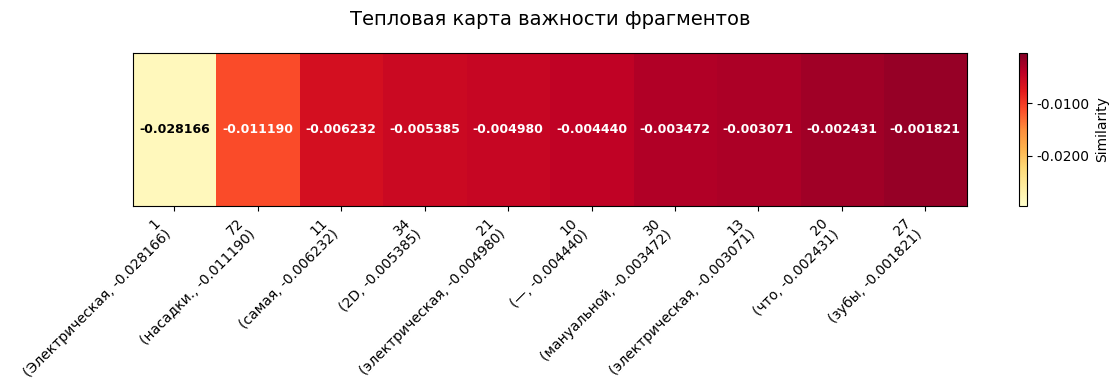

In [57]:
# Использование
fig, ax = plot_similarity_heatmap(sorted_items_last_k)
plt.show()

Диапазон похожести: [0.002947, 0.011775]
Диапазон цветовой шкалы: [0.002506, 0.012239]


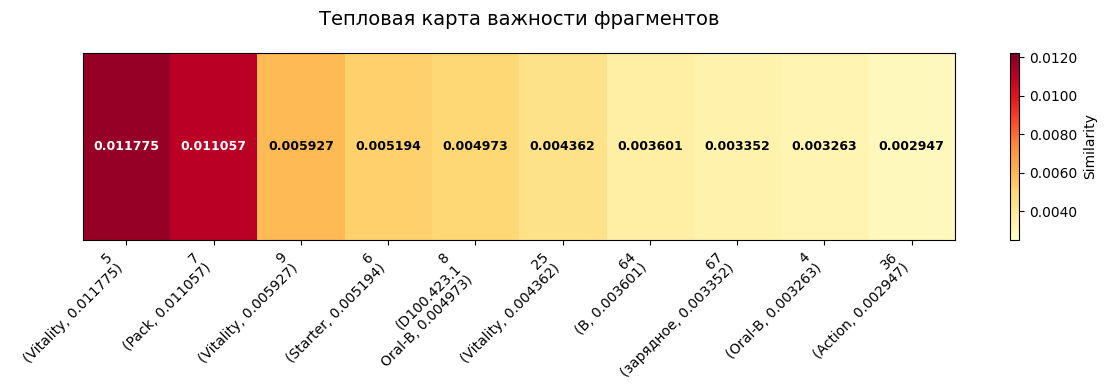

In [58]:
fig, ax = plot_similarity_heatmap(sorted_items_first_k)
plt.show()